### Hw10 Well Testing
Daniel McAllister-Ou

---
Import packages:

In [352]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Import data : 

In [353]:
import pandas as pd

data = [
    ["1/71", 1.0, 36],
    ["1/72", 4.3, 827],
    ["1/73", 71.1, 14492],
    ["1/74", 78.8, 42962],
    ["3/74", 86.5, 47976],
    ["1/75", 93.6, 76572],
    ["1/76", 93.5, 110220],
    ["1/77", 95.9, 145871],
    ["1/78", 105.5, 185580],
    ["1/79", 107.9, 222247],
    ["1/80", 100.1, 260723],
    ["1/81", 90.2, 294218],
    ["1/82", 55.8, 319134],
    ["1/83", 41.8, 336805],
    ["1/84", 29.6, 350226],
    ["1/85", 21.0, 359435],
    ["1/86", 20.6, 366902],
    ["1/87", 16.1, 373500],
    ["1/88", 16.7, 379250],
    ["1/89", 15.0, 384733],
    ["1/90", 14.6, 389898],
    ["1/91", 9.6, 394139],
    ["1/92", 12.1, 397423],
    ["1/93", 12.3, 401705],
    ["1/94", 10.6, 405830],
    ["1/95", 10.8, 409996],
    ["1/96", 9.8, 413776],
    ["1/97", 11.1, 417711],
    ["1/98", 10.4, 421449],
    ["1/99", 10.2, 425065],
]

df = pd.DataFrame(data, columns=["Date", "Oil Rate (mbbl/d)", "Cum Oil (mbbl)"])

# Optional: convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%m/%y")

# New data to append
new_data = [
    ["1/00", 9.3, 428304],
    ["1/01", 9.7, 431699],
    ["1/02", 7.6, 434718],
    ["1/03", 6.0, 437107],
    ["1/04", 6.5, 439353],
    ["1/05", 6.4, 441297],
    ["1/06", 3.5, 442841],
    ["1/07", 3.4, 444239],
    ["1/08", 4.1, 445507],
    ["1/09", 0.0, 446523],
    ["1/10", 1.6, 446591],
    ["1/11", 3.0, 447547],
]

df_new = pd.DataFrame(new_data, columns=["Date", "Oil Rate (mbbl/d)", "Cum Oil (mbbl)"])

# Convert dates
df_new["Date"] = pd.to_datetime(df_new["Date"], format="%m/%y")

# Concatenate
df = pd.concat([df, df_new], ignore_index=True)

# Sort just in case
df = df.sort_values("Date").reset_index(drop=True)

print(df.head(10))

row_dict = {"Date": None, "Oil Rate (mbbl/d)": None, "Cum Oil (mbbl)": None}
waterflood_start = row_dict.copy()
waterflood_start["Date"] = pd.to_datetime("3/74", format="%m/%y")
waterflood_start["Oil Rate (mbbl/d)"] = 86.5
waterflood_start["Cum Oil (mbbl)"] = 47976

N2wag_start = row_dict.copy()
N2wag_start["Date"] = pd.to_datetime("1/82", format="%m/%y")
N2wag_start["Oil Rate (mbbl/d)"] = 55.8
N2wag_start["Cum Oil (mbbl)"] = 319134

        Date  Oil Rate (mbbl/d)  Cum Oil (mbbl)
0 1971-01-01                1.0              36
1 1972-01-01                4.3             827
2 1973-01-01               71.1           14492
3 1974-01-01               78.8           42962
4 1974-03-01               86.5           47976
5 1975-01-01               93.6           76572
6 1976-01-01               93.5          110220
7 1977-01-01               95.9          145871
8 1978-01-01              105.5          185580
9 1979-01-01              107.9          222247


Step 1:
Plot the oil rate versus cumulative oil produced on a linear axis.  Be sure that the oil rate axis extends to q = 0.


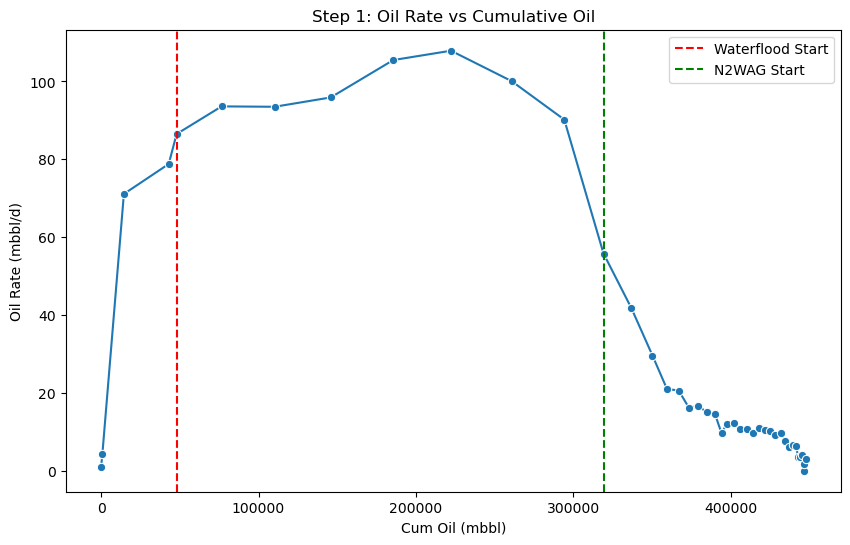

In [354]:
fig,ax = plt.subplots(figsize=(10,6))

sns.lineplot(data=df,y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',marker='o',ax=ax)
ax.axvline(waterflood_start["Cum Oil (mbbl)"], color='red', linestyle='--', label='Waterflood Start')
ax.axvline(N2wag_start["Cum Oil (mbbl)"], color='green', linestyle='--', label='N2WAG Start')
ax.legend()
ax.set_title('Step 1: Oil Rate vs Cumulative Oil')
plt.show()


Extrapolate the straight line portion of the data to determine the ultimate economic oil to be recovered from the field and the total mobile oil, both in mmbbl for both the **water** and **N2 WAG flood**.  Determine the **incremental economic oil (IOR)** and the **incremental mobile oil** caused by the N2 WAG.  

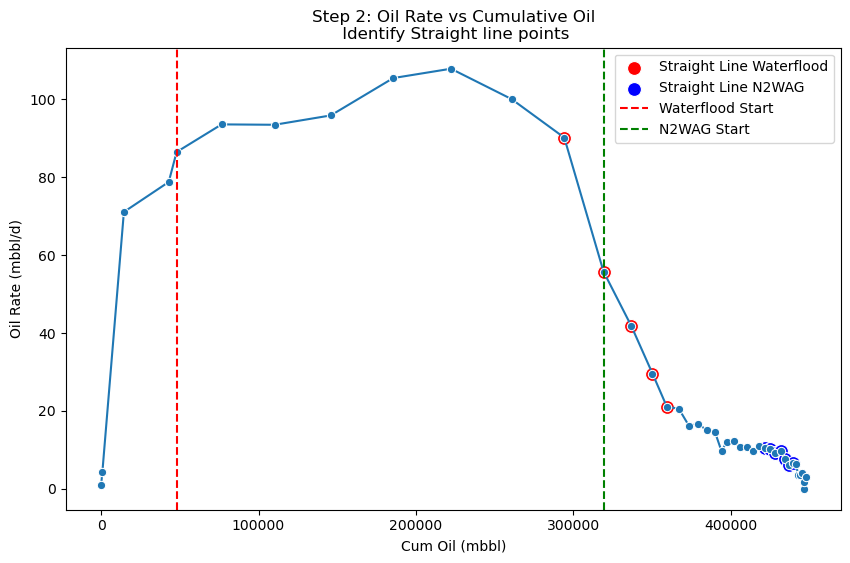

In [355]:
sl_waterflood_llim = 290000 # cum oil lim 
sl_waterflood_ulim = 360000
straight_line_waterflood_mask = (df["Cum Oil (mbbl)"] >= sl_waterflood_llim) & (df["Cum Oil (mbbl)"] <= sl_waterflood_ulim)

sl_n2_llim = 419000
sl_n2_ulim = 440000
straight_line_n2_mask = (df["Cum Oil (mbbl)"] >= sl_n2_llim) & (df["Cum Oil (mbbl)"] <= sl_n2_ulim)

fig,ax = plt.subplots(figsize=(10,6))

sns.lineplot(data=df,y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',marker='o',ax=ax)
sns.scatterplot(data=df[straight_line_waterflood_mask],y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',color='red',s=100,ax=ax,label='Straight Line Waterflood')
sns.scatterplot(data=df[straight_line_n2_mask],y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',color='blue',s=100,ax=ax,label='Straight Line N2WAG')

ax.axvline(waterflood_start["Cum Oil (mbbl)"], color='red', linestyle='--', label='Waterflood Start')
ax.axvline(N2wag_start["Cum Oil (mbbl)"], color='green', linestyle='--', label='N2WAG Start')
ax.legend()
ax.set_title('Step 2: Oil Rate vs Cumulative Oil\n Identify Straight line points')
plt.show()

linear regressions for those sl segments:

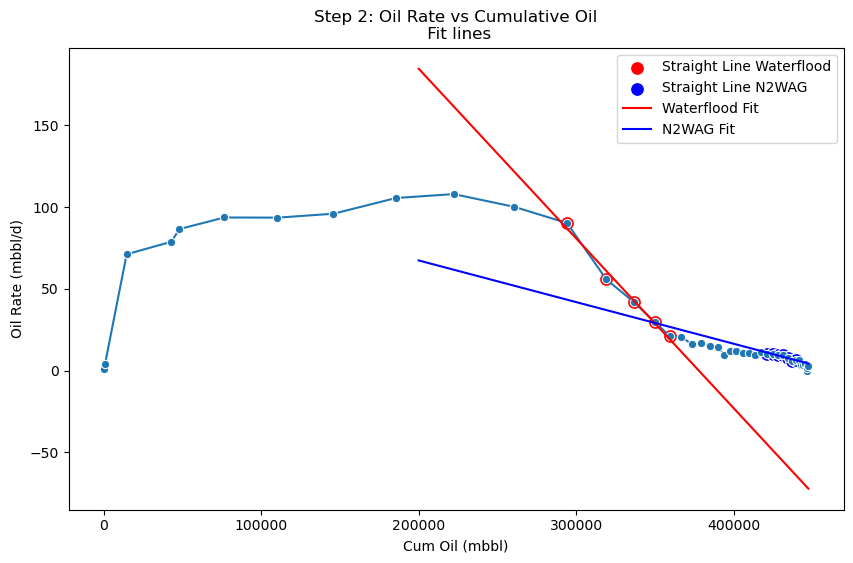

In [356]:
wf_sl_data = df[straight_line_waterflood_mask]
n2_sl_data = df[straight_line_n2_mask]

cum_fit = np.linspace(200000, df["Cum Oil (mbbl)"].max(), 100)

# np polyfit to get slope and intercept for waterflood and n2wag straight line segments
wf_slope, wf_intercept = np.polyfit(wf_sl_data["Cum Oil (mbbl)"], wf_sl_data["Oil Rate (mbbl/d)"], 1)
n2_slope, n2_intercept = np.polyfit(n2_sl_data["Cum Oil (mbbl)"], n2_sl_data["Oil Rate (mbbl/d)"], 1)

# plot the straight lines on top of the data
fig,ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df,y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',marker='o',ax=ax)
sns.scatterplot(data=df[straight_line_waterflood_mask],y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',color='red',s=100,ax=ax,label='Straight Line Waterflood')
sns.scatterplot(data=df[straight_line_n2_mask],y='Oil Rate (mbbl/d)',x='Cum Oil (mbbl)',color='blue',s=100,ax=ax,label='Straight Line N2WAG')
ax.plot(cum_fit, wf_slope * cum_fit + wf_intercept, color='red', label='Waterflood Fit')
ax.plot(cum_fit, n2_slope * cum_fit + n2_intercept, color='blue', label='N2WAG Fit')
ax.set_title('Step 2: Oil Rate vs Cumulative Oil\n Fit lines')
plt.legend()

determine the ultimate economic oil to be recovered from the field and the total mobile oil, both in mmbbl for both the **water** and **N2 WAG flood**

In [357]:
economic_limit = 1.800 # Mbopd
wf_econ_cum_oil = (economic_limit - wf_intercept) / wf_slope
n2_econ_cum_oil = (economic_limit - n2_intercept) / n2_slope
print(f'Economic Limits:')
print(f"Waterflood Economic Limit Cum Oil: {wf_econ_cum_oil/1000:.1f} mmbbl")
print(f"N2WAG Economic Limit Cum Oil: {n2_econ_cum_oil/1000:.1f} mmbbl")

wf_EUR = wf_intercept / -wf_slope
n2_EUR = n2_intercept / -n2_slope
print(f'\nEstimated Ultimate Recovery (EUR):')
print(f"Waterflood EUR: {wf_EUR/1000:.1f} mmbbl")
print(f"N2WAG EUR: {n2_EUR/1000:.1f} mmbbl")


# print(f'Waterflood Fit Params: Slope = {wf_slope:.4f}, Intercept = {wf_intercept:.2f}')
# print(f'N2WAG Fit Params: Slope = {n2_slope:.4f}, Intercept = {n2_intercept:.2f}')

Economic Limits:
Waterflood Economic Limit Cum Oil: 376.2 mmbbl
N2WAG Economic Limit Cum Oil: 457.5 mmbbl

Estimated Ultimate Recovery (EUR):
Waterflood EUR: 377.9 mmbbl
N2WAG EUR: 464.6 mmbbl


Incremental Recoveries: 

In [358]:
incremental_economic_limit =( n2_econ_cum_oil - wf_econ_cum_oil)/1000 # MMBbl
incremental_ultimate_recovery = (n2_EUR - wf_EUR)/1000 # MMBbl 

print(f"Incremental Economic Recovery = {incremental_economic_limit:.1f}")
print(f"Incremental Ultimate Recovery = {incremental_ultimate_recovery:.1f}")


Incremental Economic Recovery = 81.3
Incremental Ultimate Recovery = 86.7


**Step 3:
Determine the decline rates appropriate for the waterflood and N2 WAG flood declines.**

To find decline rates we will use equation 2:  



Currently our regressions are in the form of q = m * Np + b  
We will change our regression to the form of q = qi - a (Np - Npi)

First we will find qi and Npi for each event: 

Waterflood decline rate (a) = 0.001102
N2 WAG decline rate (a) = 0.000211


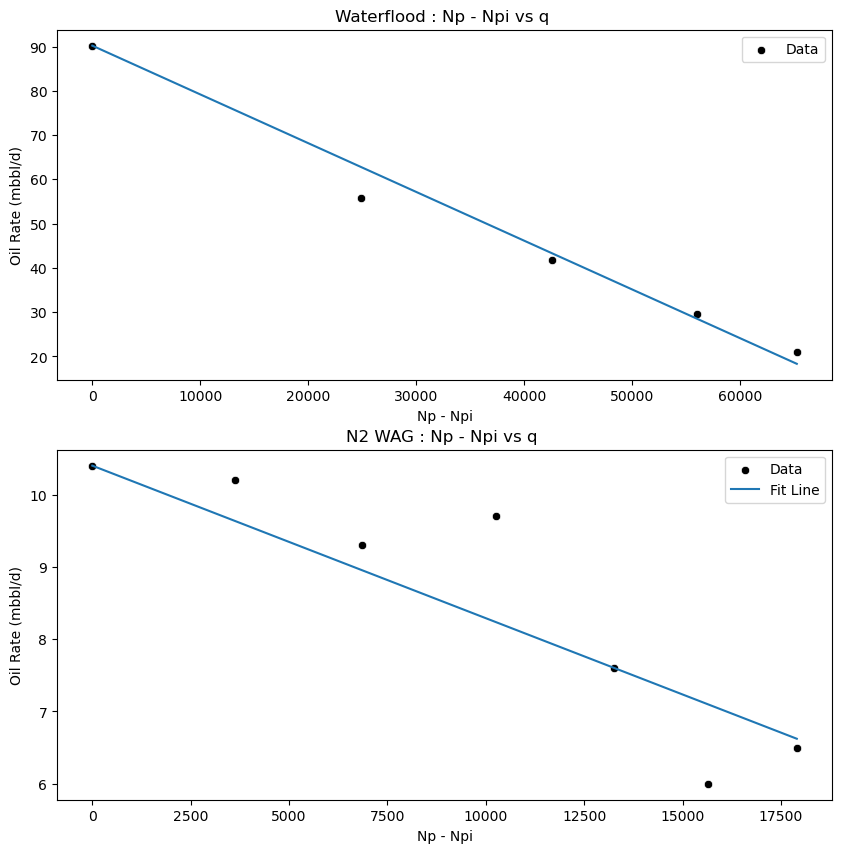

In [359]:
wf_sl_start_row = wf_sl_data.iloc[0]
n2_sl_start_row = n2_sl_data.iloc[0]

# "Oil Rate (mbbl/d)", "Cum Oil (mbbl)"
wf_Npi = wf_sl_start_row['Cum Oil (mbbl)']
n2_Npi = n2_sl_start_row['Cum Oil (mbbl)']

wf_qi = wf_sl_start_row['Oil Rate (mbbl/d)']
n2_qi = n2_sl_start_row['Oil Rate (mbbl/d)']

wf_sl_data['Np - Npi'] = wf_sl_data['Cum Oil (mbbl)'] - wf_Npi 
n2_sl_data['Np - Npi'] = n2_sl_data['Cum Oil (mbbl)'] - n2_Npi 

x_wf = wf_sl_data["Np - Npi"]
y_wf = wf_qi - wf_sl_data["Oil Rate (mbbl/d)"]

# Solve least squares for a
a_wf = np.sum(x_wf * y_wf) / np.sum(x_wf**2)

print(f"Waterflood decline rate (a) = {a_wf:.6f}")

x_n2 = n2_sl_data["Np - Npi"]
y_n2 = n2_qi - n2_sl_data["Oil Rate (mbbl/d)"]

# Solve least squares for a
a_n2 = np.sum(x_n2 * y_n2) / np.sum(x_n2**2)

print(f"N2 WAG decline rate (a) = {a_n2:.6f}")
wf_npi_np_fit = np.linspace(wf_sl_data["Np - Npi"].min(),wf_sl_data["Np - Npi"].max())
wf_fit_line = wf_qi - a_wf * wf_npi_np_fit


n2_npi_np_fit = np.linspace(n2_sl_data["Np - Npi"].min(),n2_sl_data["Np - Npi"].max())
n2_fit_line = n2_qi - a_n2 * n2_npi_np_fit

fig,ax = plt.subplots(2,1,figsize=(10,10))
sns.scatterplot(data=wf_sl_data,x='Np - Npi',y='Oil Rate (mbbl/d)',marker='o',color='k',ax=ax[0],label='Data')
ax[0].plot(wf_npi_np_fit,wf_fit_line,label='Fit Line')
ax[0].set_title('Waterflood : Np - Npi vs q ')

sns.scatterplot(data=n2_sl_data,x='Np - Npi',y='Oil Rate (mbbl/d)',marker='o',color='k',ax=ax[1],label='Data')
ax[1].plot(n2_npi_np_fit,n2_fit_line,label='Fit Line')

ax[1].set_title('N2 WAG : Np - Npi vs q ')

plt.legend();


Step 4:
Use the decline rates in Step 3 to determine the economic life of the N2 WAG flood from Eq. 1


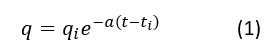

In [360]:
def solve_for_time(q, qi, a, ti):
    """
    Solve for time t given rate q using exponential decline.

    Parameters:
    q  : current rate
    qi : initial rate
    a  : decline constant
    ti : initial time

    Returns:
    t  : time corresponding to rate q
    """
    return ti + (1 / a) * np.log(qi / q)

economic_limit_q = 1.8 # Mbbl 
time_days_to_economic = solve_for_time(economic_limit_q, n2_qi, a_n2, 0)
print(f'N2 reaches economic limit in {time_days_to_economic:.0f} days or {time_days_to_economic/365.25:.2f} years')

N2 reaches economic limit in 8315 days or 22.77 years
